# Importing Libraries

In [1]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Checking the Number of GPUs available

In [2]:
import torch

print(f"Number of GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Number of GPUs available: 2
GPU 0: NVIDIA GeForce RTX 2080 Ti
GPU 1: NVIDIA GeForce RTX 2080 Ti


# Set the device to GPU if available

In [3]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:1


# Hyperparameters Tuning

In [4]:
batch_size = 32
num_epochs = 10
learning_rate = 0.001
img_rows, img_cols = 500, 400

# Directories for images

In [5]:
control_folder = 'C:/Users/RTX2080Ti/Desktop/Dyslexia DL/FCM/control'
dyslexia_folder = 'C:/Users/RTX2080Ti/Desktop/Dyslexia DL/FCM/dyslexia'

# Load and preprocess images

In [6]:
def load_images_from_folder(folder, label):
    data = []
    for imagePath in paths.list_images(folder):
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (img_cols, img_rows))
        data.append((image, label))
    return data

# Load data from both folders

In [7]:
control_data = load_images_from_folder(control_folder, 0)
dyslexia_data = load_images_from_folder(dyslexia_folder, 1)

# Combine and shuffle the data

In [8]:
data = control_data + dyslexia_data
np.random.shuffle(data)

# Separate images and labels

In [9]:
X = np.array([d[0] for d in data], dtype=np.float32)
y = np.array([d[1] for d in data], dtype=np.float32)

# Normalize the images

In [10]:
X /= 255.0

# Split the data into Train, Test & Validation

In [11]:
X_train, X_remain, y_train, y_remain = train_test_split(X, y, test_size=0.20, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_remain, y_remain, test_size=0.5, random_state=42)

# Convert to PyTorch tensors & permute dimensions

In [12]:
X_train, X_val, y_train, y_val = map(torch.tensor, (X_train, X_val, y_train, y_val))
X_train, X_val = X_train.permute(0, 3, 1, 2), X_val.permute(0, 3, 1, 2)
y_train, y_val = y_train.unsqueeze(1), y_val.unsqueeze(1)  # Match target shape for BCELoss

# Prepare the DataLoader

In [13]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# CNN Model

In [14]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * (img_rows // 4) * (img_cols // 4), 64)  
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# Instantiate the model, loss function & optimizer

In [15]:
model = CNNModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training & Validation

In [16]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    # Validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item() * data.size(0)
            pred = (output > 0.5).float()
            correct += pred.eq(target).sum().item()

    # Calculate average losses and accuracy
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    accuracy = correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}')


Epoch 1/10, Train Loss: 0.4998, Val Loss: 0.1497, Accuracy: 0.9524
Epoch 2/10, Train Loss: 0.1121, Val Loss: 0.0742, Accuracy: 0.9812
Epoch 3/10, Train Loss: 0.1061, Val Loss: 0.1023, Accuracy: 0.9762
Epoch 4/10, Train Loss: 0.0255, Val Loss: 0.0072, Accuracy: 0.9962
Epoch 5/10, Train Loss: 0.0121, Val Loss: 0.0038, Accuracy: 0.9987
Epoch 6/10, Train Loss: 0.0095, Val Loss: 0.0033, Accuracy: 1.0000
Epoch 7/10, Train Loss: 0.0073, Val Loss: 0.0011, Accuracy: 1.0000
Epoch 8/10, Train Loss: 0.0073, Val Loss: 0.0198, Accuracy: 0.9962
Epoch 9/10, Train Loss: 0.0164, Val Loss: 0.0102, Accuracy: 0.9975
Epoch 10/10, Train Loss: 0.0041, Val Loss: 0.0001, Accuracy: 1.0000


# Load the test data

In [17]:
X_test, y_test = map(torch.tensor, (X_test, y_test))
X_test = X_test.permute(0, 3, 1, 2).float()
y_test = y_test.float()

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)

# Evaluate the Model on the Test Data

In [18]:
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output.squeeze(), target).item()
        pred = output.round()
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

test_loss /= len(test_loader.dataset)
accuracy = correct / total
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss: 0.0000
Test Accuracy: 100.00%


# Saving the model

In [19]:
torch.save(model.state_dict(), 'cnn_pytorch_model.pth')

Confusion Matrix:
[[451   0]
 [  0 348]]
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000


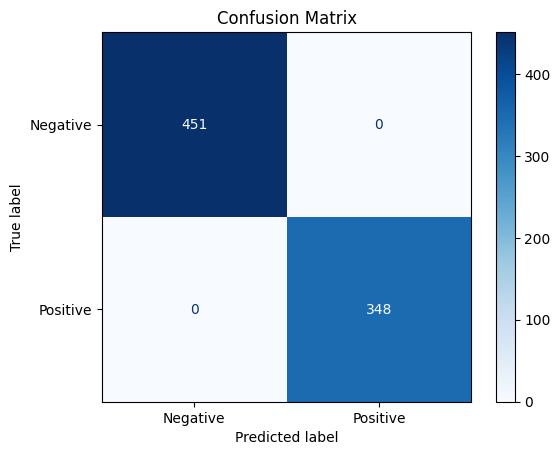

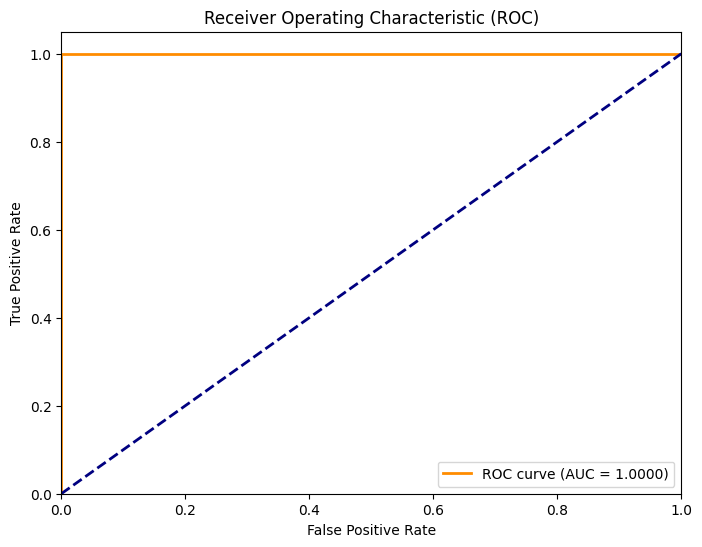

In [20]:
import numpy as np
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)          # shape: (batch, 1) or (batch,)
        
        # Probabilities for ROC-AUC
        probs = output.cpu().numpy().flatten()
        # Predictions (threshold 0.5)
        preds = (output > 0.5).float().cpu().numpy().flatten()
        
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(target.cpu().numpy().flatten())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# ======================
# Metrics Calculation
# ======================

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Precision, Recall, F1-score
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# ROC-AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC:   {roc_auc:.4f}")

# ======================
# Visualizations
# ======================

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       451
    Positive       1.00      1.00      1.00       348

    accuracy                           1.00       799
   macro avg       1.00      1.00      1.00       799
weighted avg       1.00      1.00      1.00       799



# Confusion Matrix

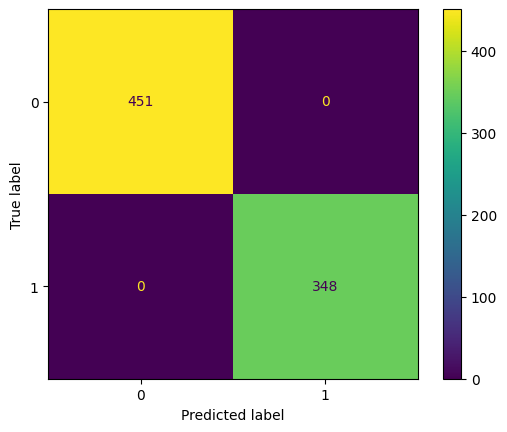

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicting on the test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        preds = output.round()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(target.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Generating the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ROC Curve (for binary classification)

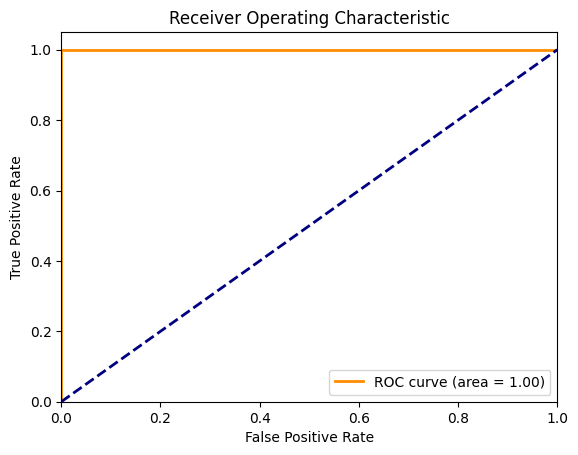

In [23]:
from sklearn.metrics import roc_curve, auc

# Calculating probabilities and ROC curve
model.eval()
all_probs = []
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        all_probs.append(output.cpu().numpy())

all_probs = np.concatenate(all_probs)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

XAI - Gradcam++

In [24]:
# Find correctly classified control and dyslexic samples from your test set
model.eval()
correct_control_idx  = []
correct_dyslexic_idx = []

with torch.no_grad():
    for i, (img, label) in enumerate(zip(X_test, y_test)):
        out  = model(img.unsqueeze(0).to(device))
        pred = int(out.item() > 0.5)
        true = int(label.item())
        if pred == true == 0:
            correct_control_idx.append(i)
        elif pred == true == 1:
            correct_dyslexic_idx.append(i)

print(f"Correctly classified controls:  {len(correct_control_idx)}")
print(f"Correctly classified dyslexics: {len(correct_dyslexic_idx)}")

Correctly classified controls:  451
Correctly classified dyslexics: 348


STEP 2: Computing averaged Grad-CAM++ maps

Processing 100 control samples …
  Control: processed 25/100 samples …
  Control: processed 50/100 samples …
  Control: processed 75/100 samples …
  Control: processed 100/100 samples …
  Control: done (100 successful CAMs)

Processing 100 dyslexic samples …
  Dyslexic: processed 25/100 samples …
  Dyslexic: processed 50/100 samples …
  Dyslexic: processed 75/100 samples …
  Dyslexic: processed 100/100 samples …
  Dyslexic: done (100 successful CAMs)

Hooks removed. CAM accumulation complete.

STEP 3: Extracting discriminative channel pairs

Top 30 discriminative channel pairs — CONTROL
Rank   Ch_i     Ch_j     Mean CAM  
-----------------------------------
1      E103     E117     0.7184
2      E102     E108     0.6687
3      E38      E40      0.6685
4      E100     E110     0.6657
5      E7       E12      0.6568
6      E103     E108     0.6516
7      E101     E109     0.6489
8      E101     E110     0.6194
9      E103     E118     0.6089
10

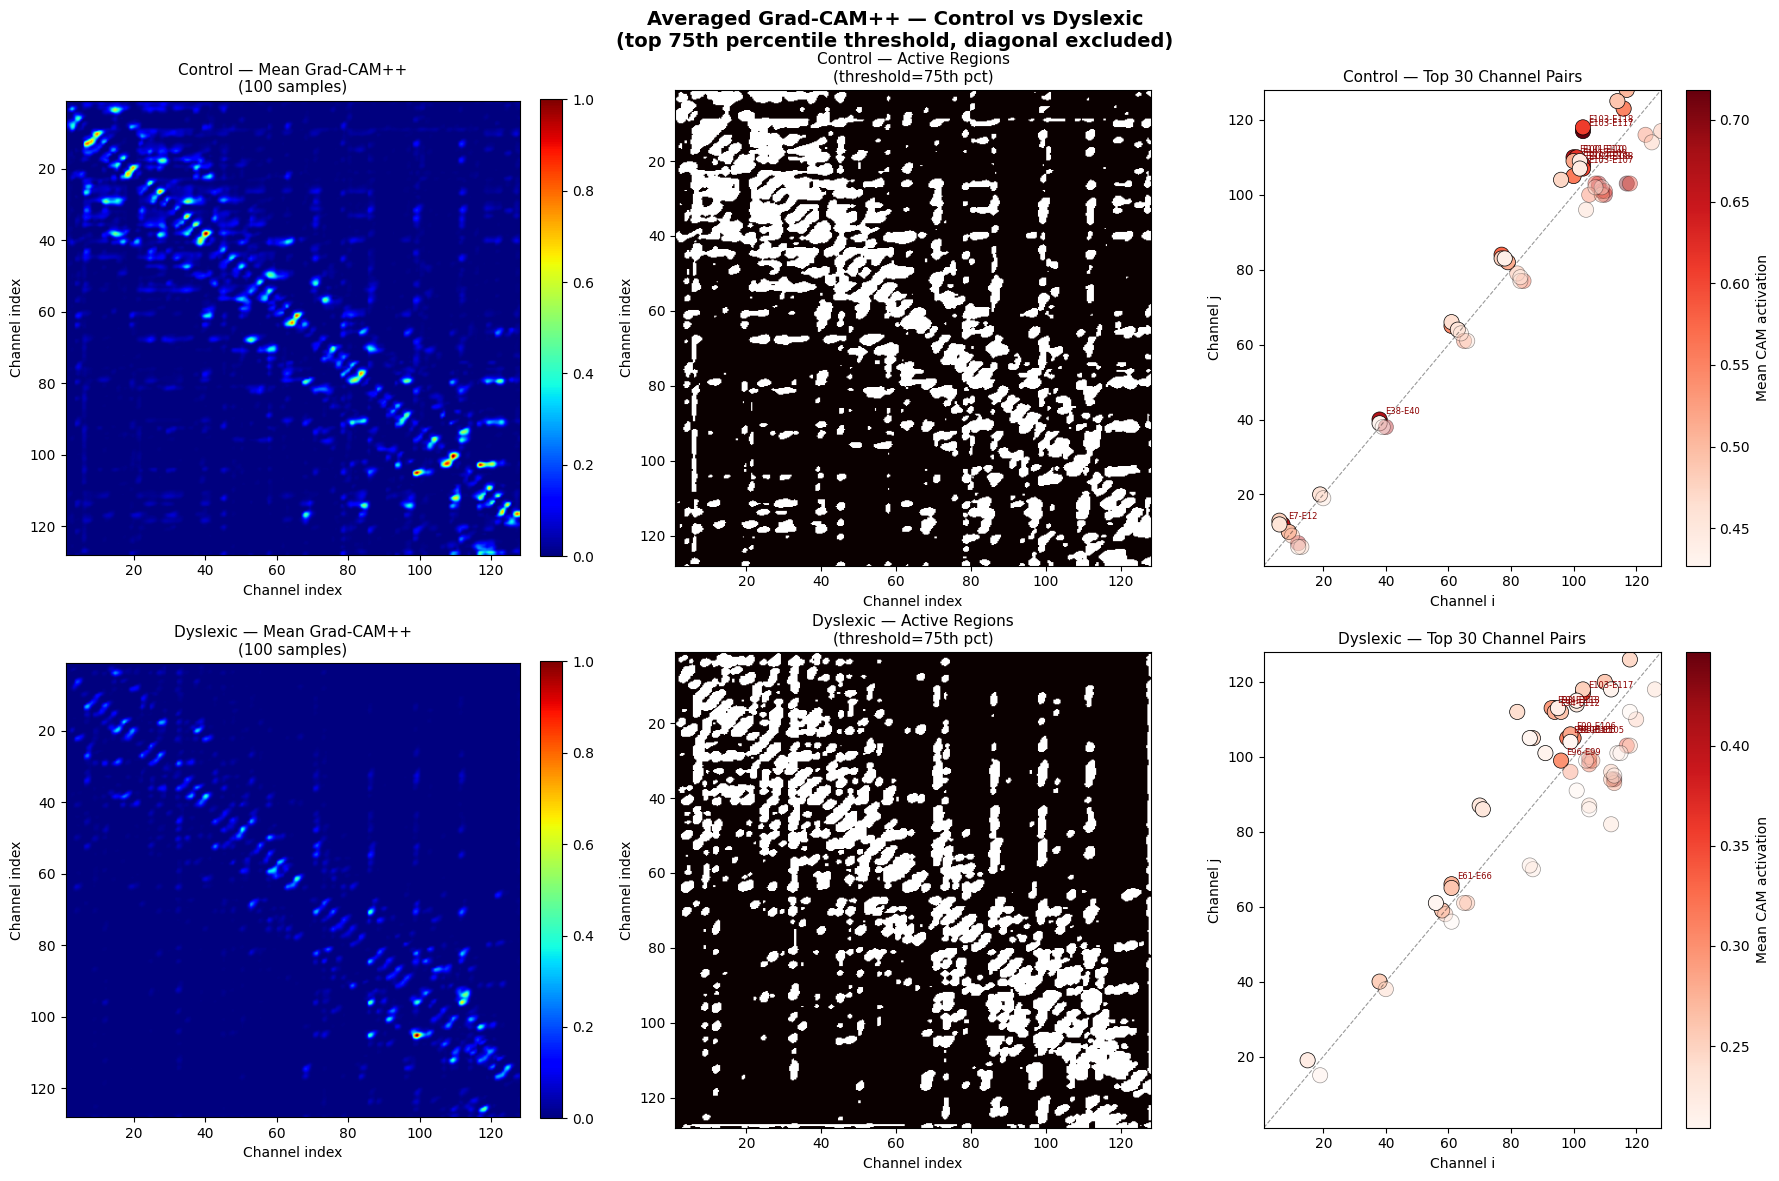


Saved → gradcam_averaged_channel_pairs.png
Saved → channel_pairs_control.csv
Saved → channel_pairs_dyslexic.csv


In [25]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from collections import defaultdict

# Config 
img_rows, img_cols = 500, 400   
N_CHANNELS         = 128        
TOP_N_PAIRS        = 30         
CAM_THRESHOLD      = 0.75       
MAX_SAMPLES        = 100        
                                

# Grad-CAM++ class 
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd = target_layer.register_forward_hook(self._save_act)
        self._bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor):
        """Returns CAM (H,W) in [0,1], pred_label, pred_prob."""
        input_tensor = input_tensor.to(device)
        self.model.zero_grad()
        output     = self.model(input_tensor)       # (1,1)
        pred_prob  = output.item()
        pred_label = int(pred_prob > 0.5)

        output.backward()

        A   = self.activations                      # (1, C, h, w)
        dS  = self.gradients                        # (1, C, h, w)
        eps = 1e-7
        dS2 = dS ** 2
        dS3 = dS ** 3
        global_sum = A.sum(dim=(2, 3), keepdim=True)
        alpha      = dS2 / (2.0 * dS2 + global_sum * dS3 + eps)
        weights    = (alpha * F.relu(dS)).sum(dim=(2, 3))   # (1, C)

        cam = (weights[:, :, None, None] * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        c_min, c_max = cam.min(), cam.max()
        cam = (cam - c_min) / (c_max - c_min + eps)
        return cam, pred_label, pred_prob

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()


# Helper: pixel → channel pair
def pixel_to_channel(r, c, img_h=img_rows, img_w=img_cols, n_ch=N_CHANNELS):
    ch_row = int(r / img_h * n_ch) + 1   # E{ch_row}
    ch_col = int(c / img_w * n_ch) + 1   # E{ch_col}
    return ch_row, ch_col


# Step 2: Accumulate CAMs per class
print("=" * 60)
print("STEP 2: Computing averaged Grad-CAM++ maps")
print("=" * 60)

gradcam_pp = GradCAMPlusPlus(model, target_layer=model.conv5)
model.eval()

# Sample indices (cap at MAX_SAMPLES for speed)
np.random.seed(42)
ctrl_indices = np.random.choice(correct_control_idx,
                                 min(MAX_SAMPLES, len(correct_control_idx)),
                                 replace=False)
dys_indices  = np.random.choice(correct_dyslexic_idx,
                                 min(MAX_SAMPLES, len(correct_dyslexic_idx)),
                                 replace=False)

def accumulate_cams(indices, class_name):
    """Run Grad-CAM++ over all indices, return mean CAM (img_rows, img_cols)."""
    cam_sum   = np.zeros((img_rows, img_cols), dtype=np.float64)
    n_success = 0

    for i, idx in enumerate(indices):
        img_tensor = X_test[idx].unsqueeze(0).float()   # (1, 3, H, W)
        try:
            cam, pred_label, pred_prob = gradcam_pp.generate(img_tensor)
            # Upsample CAM from conv5 spatial size → full image size
            cam_up = cv2.resize(cam, (img_cols, img_rows),
                                interpolation=cv2.INTER_LINEAR)
            cam_sum   += cam_up
            n_success += 1
        except Exception as e:
            print(f"  [warn] sample {idx} failed: {e}")

        if (i + 1) % 25 == 0:
            print(f"  {class_name}: processed {i+1}/{len(indices)} samples …")

    mean_cam = cam_sum / max(n_success, 1)
    # Re-normalise the mean map to [0,1]
    mn, mx   = mean_cam.min(), mean_cam.max()
    mean_cam = (mean_cam - mn) / (mx - mn + 1e-7)
    print(f"  {class_name}: done ({n_success} successful CAMs)")
    return mean_cam

print(f"\nProcessing {len(ctrl_indices)} control samples …")
mean_cam_ctrl = accumulate_cams(ctrl_indices, "Control")

print(f"\nProcessing {len(dys_indices)} dyslexic samples …")
mean_cam_dys  = accumulate_cams(dys_indices,  "Dyslexic")

gradcam_pp.remove_hooks()
print("\nHooks removed. CAM accumulation complete.")


# Step 3: Map high-activation regions → channel pairs
print("\n" + "=" * 60)
print("STEP 3: Extracting discriminative channel pairs")
print("=" * 60)

def extract_channel_pairs(mean_cam, threshold_percentile=CAM_THRESHOLD * 100,
                           top_n=TOP_N_PAIRS):
    """
    Threshold the mean CAM, find activated pixels,
    convert to channel pairs, and rank by mean CAM value.

    Returns a sorted list of (ch_i, ch_j, mean_activation) tuples.
    """
    threshold   = np.percentile(mean_cam, threshold_percentile)
    binary_mask = (mean_cam >= threshold).astype(np.uint8)

    # Accumulate activation per channel pair
    pair_activation = defaultdict(list)
    ys, xs = np.where(binary_mask)

    for r, c in zip(ys, xs):
        ch_i, ch_j = pixel_to_channel(r, c)
        # Skip diagonal (self-connectivity — trivially always 1.0)
        if ch_i == ch_j:
            continue
        # Canonical ordering so (E3,E10) and (E10,E3) are the same pair
        key = (min(ch_i, ch_j), max(ch_i, ch_j))
        pair_activation[key].append(mean_cam[r, c])

    # Rank by mean activation strength
    ranked = sorted(
        [(f"E{k[0]}", f"E{k[1]}", float(np.mean(v)))
         for k, v in pair_activation.items()],
        key=lambda x: x[2], reverse=True
    )
    return ranked[:top_n], binary_mask, threshold


ctrl_pairs, ctrl_mask, ctrl_thresh = extract_channel_pairs(mean_cam_ctrl)
dys_pairs,  dys_mask,  dys_thresh  = extract_channel_pairs(mean_cam_dys)


# ── Print ranked channel pairs ────────────────────────────────────────────────
def print_pairs(pairs, class_name):
    print(f"\nTop {len(pairs)} discriminative channel pairs — {class_name}")
    print(f"{'Rank':<6} {'Ch_i':<8} {'Ch_j':<8} {'Mean CAM':<10}")
    print("-" * 35)
    for rank, (ci, cj, act) in enumerate(pairs, 1):
        print(f"{rank:<6} {ci:<8} {cj:<8} {act:.4f}")

print_pairs(ctrl_pairs, "CONTROL")
print_pairs(dys_pairs,  "DYSLEXIC")


# ── Identify pairs unique to each class (not shared) ─────────────────────────
ctrl_set = {(p[0], p[1]) for p in ctrl_pairs}
dys_set  = {(p[0], p[1]) for p in dys_pairs}

ctrl_unique = ctrl_set - dys_set
dys_unique  = dys_set  - ctrl_set
shared      = ctrl_set & dys_set

print(f"\nPairs unique to Control:  {len(ctrl_unique)}")
print(f"Pairs unique to Dyslexic: {len(dys_unique)}")
print(f"Shared pairs:             {len(shared)}")
if shared:
    print(f"  Shared: {sorted(shared)}")


# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Averaged Grad-CAM++ — Control vs Dyslexic\n"
             f"(top {CAM_THRESHOLD*100:.0f}th percentile threshold, "
             f"diagonal excluded)",
             fontsize=14, fontweight="bold")

class_data = [
    ("Control",  mean_cam_ctrl, ctrl_mask, ctrl_pairs),
    ("Dyslexic", mean_cam_dys,  dys_mask,  dys_pairs),
]

for row, (cname, mean_cam, mask, pairs) in enumerate(class_data):

    # Col 0 — averaged CAM heatmap
    ax = axes[row, 0]
    im = ax.imshow(mean_cam, cmap="jet", vmin=0, vmax=1,
                   extent=[1, N_CHANNELS, N_CHANNELS, 1])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{cname} — Mean Grad-CAM++\n({len(ctrl_indices if row==0 else dys_indices)} samples)",
                 fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # Col 1 — thresholded mask (binary)
    ax = axes[row, 1]
    ax.imshow(mask, cmap="hot", vmin=0, vmax=1,
              extent=[1, N_CHANNELS, N_CHANNELS, 1])
    ax.set_title(f"{cname} — Active Regions\n(threshold={CAM_THRESHOLD*100:.0f}th pct)", fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # Col 2 — scatter plot of top channel pairs
    ax = axes[row, 2]
    if pairs:
        ci_nums  = [int(p[0][1:]) for p in pairs]
        cj_nums  = [int(p[1][1:]) for p in pairs]
        strengths = [p[2] for p in pairs]
        sc = ax.scatter(ci_nums, cj_nums, c=strengths, cmap="Reds",
                        s=120, edgecolors="black", linewidths=0.5,
                        vmin=min(strengths), vmax=max(strengths))
        # Mirror across diagonal (connectivity is symmetric)
        ax.scatter(cj_nums, ci_nums, c=strengths, cmap="Reds",
                   s=120, edgecolors="black", linewidths=0.5,
                   vmin=min(strengths), vmax=max(strengths), alpha=0.4)
        plt.colorbar(sc, ax=ax, label="Mean CAM activation")
        # Annotate top 10
        for p in pairs[:10]:
            ci, cj = int(p[0][1:]), int(p[1][1:])
            ax.annotate(f"{p[0]}-{p[1]}", (ci, cj),
                        textcoords="offset points", xytext=(4, 4),
                        fontsize=6, color="darkred")
    ax.set_xlim(1, N_CHANNELS)
    ax.set_ylim(1, N_CHANNELS)
    ax.set_xlabel("Channel i")
    ax.set_ylabel("Channel j")
    ax.set_title(f"{cname} — Top {TOP_N_PAIRS} Channel Pairs", fontsize=11)
    ax.plot([1, N_CHANNELS], [1, N_CHANNELS], 'k--', lw=0.8, alpha=0.4,
            label="Diagonal")

plt.tight_layout()
plt.savefig("gradcam_averaged_channel_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → gradcam_averaged_channel_pairs.png")


# Export to CSV
import csv

for class_name, pairs in [("Control", ctrl_pairs), ("Dyslexic", dys_pairs)]:
    fname = f"channel_pairs_{class_name.lower()}.csv"
    with open(fname, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Rank", "Channel_i", "Channel_j",
                         "Mean_CAM_Activation", "Class"])
        for rank, (ci, cj, act) in enumerate(pairs, 1):
            writer.writerow([rank, ci, cj, f"{act:.6f}", class_name])
    print(f"Saved → {fname}")